In [1]:
import numpy as np
import matplotlib.pyplot as plt

***Part A***

In [2]:
def collide_1d(m1, m2, u1, u2, e):
    total_m = m1 + m2

    # Center-of-mass velocity is unchanged by the collision
    v_cm = (m1 * u1 + m2 * u2) / total_m

    v1 = v_cm - e * (m2 / total_m) * (u1 - u2)
    v2 = v_cm + e * (m1 / total_m) * (u1 - u2)

    p_total = m1 * u1 + m2 * u2
    ke_total = 0.5 * m1 * u1**2 + 0.5 * m2 * u2**2

    return v_cm, v1, v2, p_total, ke_total

print(collide_1d(1.0, 1.0, 3.0, 0.0, 1.0))

(1.5, 0.0, 3.0, 3.0, 4.5)


In [3]:
for e in [1.0, 0.5, 0.0]:
    v_cm, v1, v2, p_before, ke_before = collide_1d(
        2.0, 3.0, 4.0, 0.0, e
    )

    p_after = 2.0 * v1 + 3.0 * v2
    ke_after = 0.5 * 2.0 * v1**2 + 0.5 * 3.0 * v2**2

    print(e, v1, v2, p_before, p_after, ke_before, ke_after)


1.0 -0.7999999999999998 3.2 8.0 8.000000000000002 16.0 16.000000000000004
0.5 0.40000000000000013 2.4000000000000004 8.0 8.000000000000002 16.0 8.800000000000002
0.0 1.6 1.6 8.0 8.0 16.0 6.400000000000001



e      v1     v2   p_be   p_a   ke_b   ke_a
1.0 | -0.79 | 3.2 | 8.0 | 8.0 | 16.0 | 16.0
0.5 |  0.40 | 2.4 | 8.0 | 8.0 | 16.0 | 8.80
0.0 |  1.6  | 1.6 | 8.0 | 8.0 | 16.0 | 6.40

Momentum is identical across all three e values, but KE drops as e shrinks. Where did the missing KE go, physically?

***Part B***

In [4]:
def collide_2d(m1, m2, r1, r2, v1, v2, e=1.0):
    """Resolve a 2D collision between two circular balls."""

    r1 = np.asarray(r1, float)
    r2 = np.asarray(r2, float)
    v1 = np.asarray(v1, float)
    v2 = np.asarray(v2, float)

    # Line of centers
    n = r2 - r1
    distance = np.linalg.norm(n)

    if distance == 0:
        return v1, v2

    # Unit normal vector
    n = n / distance

    # Velocity components along the normal
    u1n = np.dot(v1, n)
    u2n = np.dot(v2, n)

    # Tangential components remain unchanged
    v1t = v1 - u1n * n
    v2t = v2 - u2n * n

    # Apply 1D collision to normal components
    _, new1n, new2n, _, _ = collide_1d(
        m1, m2, u1n, u2n, e
    )

    # Recombine normal and tangential components
    new_v1 = v1t + new1n * n
    new_v2 = v2t + new2n * n

    return new_v1, new_v2

In [5]:
def update_ball(r, v, R, W, H):

    # Left/right walls
    if r[0] - R < 0:
        r[0] = R
        v[0] = -v[0]

    elif r[0] + R > W:
        r[0] = W - R
        v[0] = -v[0]

    # Bottom/top walls
    if r[1] - R < 0:
        r[1] = R
        v[1] = -v[1]

    elif r[1] + R > H:
        r[1] = H - R
        v[1] = -v[1]

    return r, v

In [6]:
# Box dimensions
W = 10.0
H = 8.0

# Ball 1
m1 = 2.0
R1 = 0.5
r1 = np.array([2.0, 3.0])
v1 = np.array([2.0, 0.8])

# Ball 2
m2 = 3.0
R2 = 0.7
r2 = np.array([8.0, 5.0])
v2 = np.array([-1.5, -0.4])

# Elastic collision
e = 1.0

# Time
dt = 0.01
steps = 300

# Storage
positions1 = []
positions2 = []
px_total = []
py_total = []
ke_total = []
times = []

for step in range(steps):

    # Euler-Cromer position update
    r1 = r1 + v1 * dt
    r2 = r2 + v2 * dt

    # Wall collisions
    r1, v1 = update_ball(r1, v1, R1, W, H)
    r2, v2 = update_ball(r2, v2, R2, W, H)

    # Distance between balls
    separation = r2 - r1
    distance = np.linalg.norm(separation)

    # Ball-ball collision
    if distance < R1 + R2:

        # Only resolve if balls are approaching
        if np.dot(v2 - v1, r2 - r1) < 0:

            v1, v2 = collide_2d(
                m1, m2,
                r1, r2,
                v1, v2,
                e
            )

            # Remove overlap
            n = separation / distance
            overlap = R1 + R2 - distance

            r1 = r1 - 0.5 * overlap * n
            r2 = r2 + 0.5 * overlap * n

    # Store positions
    positions1.append(r1.copy())
    positions2.append(r2.copy())

    # Total momentum
    px_total.append(m1 * v1[0] + m2 * v2[0])
    py_total.append(m1 * v1[1] + m2 * v2[1])

    # Total kinetic energy
    ke_total.append(
        0.5 * m1 * np.dot(v1, v1)
        + 0.5 * m2 * np.dot(v2, v2)
    )

    times.append(step * dt)

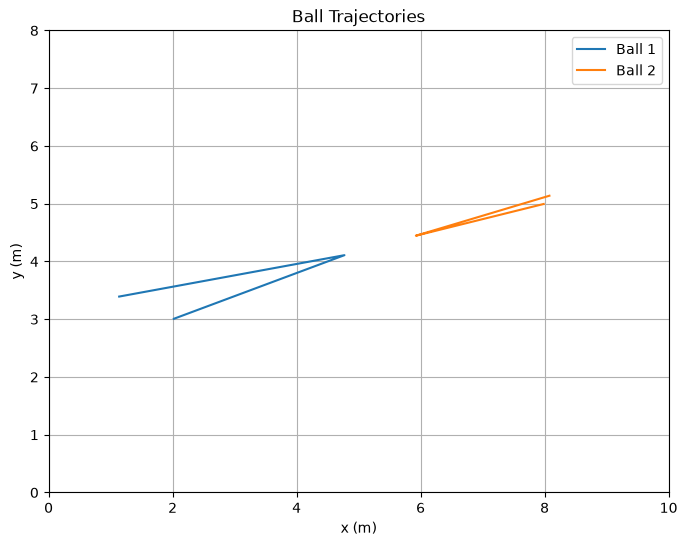

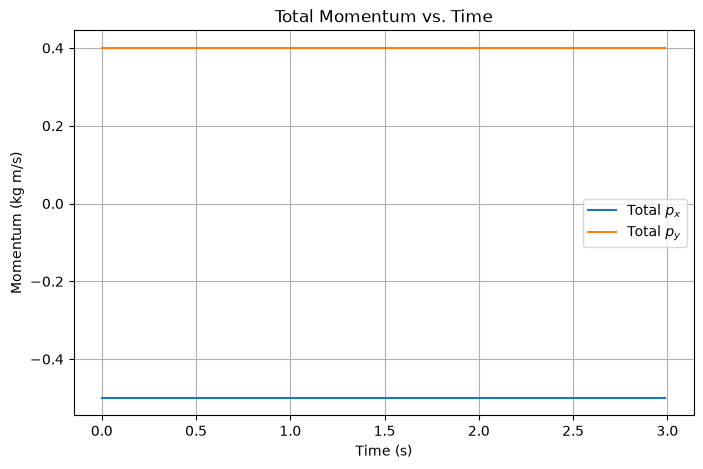

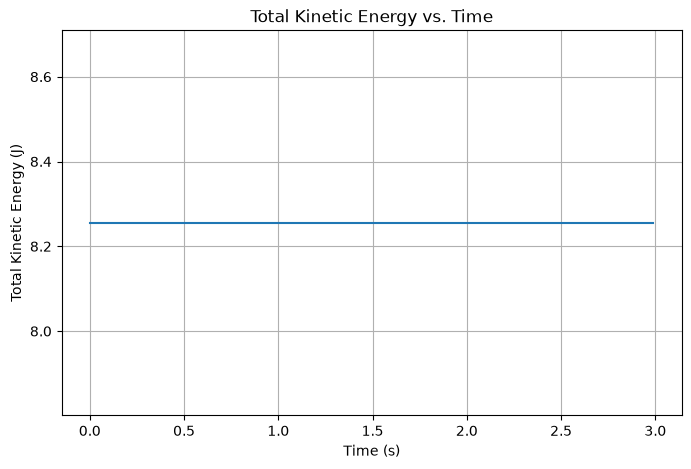

In [7]:
positions1 = np.array(positions1)
positions2 = np.array(positions2)

times = np.array(times)
px_total = np.array(px_total)
py_total = np.array(py_total)
ke_total = np.array(ke_total)


plt.figure(figsize=(8, 6))

plt.plot(positions1[:, 0], positions1[:, 1], label="Ball 1")
plt.plot(positions2[:, 0], positions2[:, 1], label="Ball 2")

plt.xlim(0, W)
plt.ylim(0, H)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Ball Trajectories")
plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(times, px_total, label="Total $p_x$")
plt.plot(times, py_total, label="Total $p_y$")

plt.xlabel("Time (s)")
plt.ylabel("Momentum (kg m/s)")
plt.title("Total Momentum vs. Time")
plt.legend()
plt.grid()

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(times, ke_total)

plt.xlabel("Time (s)")
plt.ylabel("Total Kinetic Energy (J)")
plt.title("Total Kinetic Energy vs. Time")
plt.grid()

plt.show()

**With elastic collisions and elastic walls, what should total KE do over time? Does yours? What about total momentum — and why does bouncing off a wall change it? (Think about what the wall represents.)**

In an elastic system, where e = 1, the total kinetic energy should remain approximately constant because both ball-ball and ball-wall collisions are elastic. The total momentum is conserved during ball-ball collisions, but it changes when a ball strikes a wall because the wall exerts an external force on the two-ball system.

***Part C***

In [8]:
def run_simulation(e, steps=300, dt=0.01, use_walls=True):

    # Box
    W = 10.0
    H = 8.0

    # Initial conditions
    m1 = 2.0
    m2 = 3.0

    R1 = 0.5
    R2 = 0.7

    r1 = np.array([2.0, 3.0], dtype=float)
    r2 = np.array([8.0, 5.0], dtype=float)

    v1 = np.array([2.0, 0.8], dtype=float)
    v2 = np.array([-1.5, -0.4], dtype=float)

    # Storage
    times = []
    ke = []
    trajectories1 = []
    trajectories2 = []

    first_collision_ke_before = None
    first_collision_ke_after = None

    for step in range(steps):

        # Euler-Cromer
        r1 = r1 + v1 * dt
        r2 = r2 + v2 * dt

        # Wall collisions
        if use_walls:
            r1, v1 = update_ball(r1, v1, R1, W, H)
            r2, v2 = update_ball(r2, v2, R2, W, H)

        # Ball-ball collision
        dr = r2 - r1
        distance = np.linalg.norm(dr)

        if distance < R1 + R2 and distance > 0:

            # Only collide if approaching
            if np.dot(v2 - v1, r2 - r1) < 0:

                # KE immediately before collision
                ke_before = (
                    0.5 * m1 * np.dot(v1, v1)
                    + 0.5 * m2 * np.dot(v2, v2)
                )

                # Resolve collision
                v1, v2 = collide_2d(
                    m1, m2,
                    r1, r2,
                    v1, v2,
                    e
                )

                # KE immediately after collision
                ke_after = (
                    0.5 * m1 * np.dot(v1, v1)
                    + 0.5 * m2 * np.dot(v2, v2)
                )

                # Save only the first collision
                if first_collision_ke_before is None:
                    first_collision_ke_before = ke_before
                    first_collision_ke_after = ke_after

                # Remove overlap
                n = dr / distance
                overlap = R1 + R2 - distance

                r1 -= 0.5 * overlap * n
                r2 += 0.5 * overlap * n

        # Store data
        times.append(step * dt)

        trajectories1.append(r1.copy())
        trajectories2.append(r2.copy())

        total_ke = (
            0.5 * m1 * np.dot(v1, v1)
            + 0.5 * m2 * np.dot(v2, v2)
        )

        ke.append(total_ke)

    return (
        np.array(times),
        np.array(ke),
        np.array(trajectories1),
        np.array(trajectories2),
        first_collision_ke_before,
        first_collision_ke_after
    )

In [9]:
e_values = [1.0, 0.9, 0.7, 0.5]

results = {}

for e in e_values:
    results[e] = run_simulation(e)

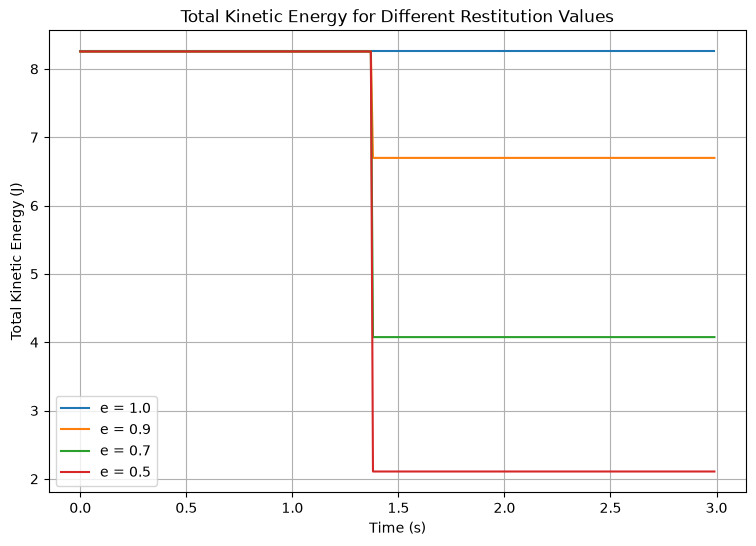

In [10]:
plt.figure(figsize=(9, 6))

for e in e_values:
    times = results[e][0]
    ke = results[e][1]

    plt.plot(times, ke, label=f"e = {e}")

plt.xlabel("Time (s)")
plt.ylabel("Total Kinetic Energy (J)")
plt.title("Total Kinetic Energy for Different Restitution Values")
plt.legend()
plt.grid()

plt.show()

In [11]:
for e in e_values:

    ke_before = results[e][4]
    ke_after = results[e][5]

    fraction_lost = (ke_before - ke_after) / ke_before

    print(
        f"e = {e:.1f}: "
        f"KE lost = {fraction_lost:.6f} "
        f"({100*fraction_lost:.2f}%)"
    )

e = 1.0: KE lost = 0.000000 (0.00%)
e = 0.9: KE lost = 0.188661 (18.87%)
e = 0.7: KE lost = 0.506407 (50.64%)
e = 0.5: KE lost = 0.744716 (74.47%)


In [12]:
times, ke, traj1, traj2, _, _ = run_simulation(
    e=1.0,
    steps=300,
    dt=0.01,
    use_walls=False
)


m1 = 2.0
m2 = 3.0

r_cm = (m1 * traj1 + m2 * traj2) / (m1 + m2)

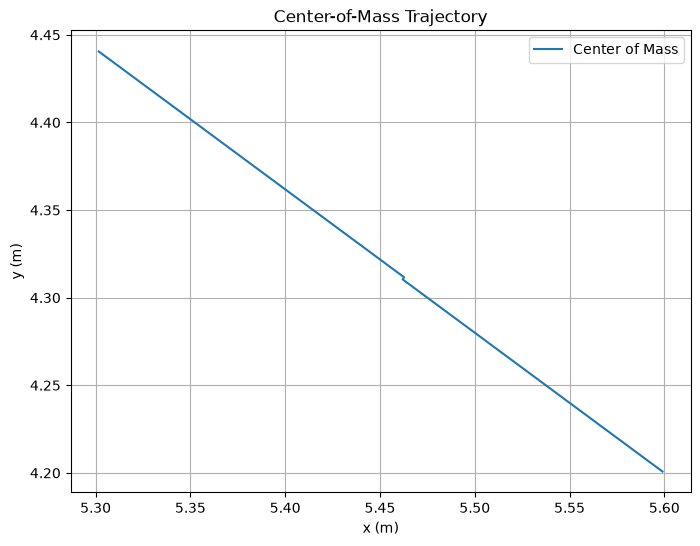

In [13]:
plt.figure(figsize=(8, 6))

plt.plot(
    r_cm[:, 0],
    r_cm[:, 1],
    label="Center of Mass"
)

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Center-of-Mass Trajectory")
plt.legend()
plt.grid()

plt.show()

**The trajectory of the system's center of mass for the elastic case with no walls (let the balls fly off after colliding) should move in a straight line at constant velocity. Explain why this is a powerful correctness check.**

This is a good correctness check. Since this is an elastic collision, total momentum remains constant, thus the velocity of the center of mass stays constant.

**For e < 1, does total KE ever increase at any step? What would it mean about your code if it did? Why is "KE never increases" a valid test even without an exact solution?**

This is valid since e is a characteristic of how elastic a collision is. In an inelastic collision, KE energy decreases as it is lost as heat, sound, and deformation. At e = 0, this represents a perfectly inelastic collision where the objects stick together maximizing kinetic energy loss.